In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import scvelo as scv

In [2]:
method = "velovae_std"
DATA_DIR = Path(f"{method}")

In [3]:
data_configs = {
    "04": ("data04", "uncertainty_data04.npy",   "emb_coords_data04.npy"),
    "17": ("data17", "uncertainty_data17.npy", "emb_coords_data17.npy"),
    "18": ("data18", "uncertainty_data18.npy", "emb_coords_data18.npy"),
    "19": ("data19", "uncertainty_data19.npy", "emb_coords_data19.npy"),
    "20": ("data20", "uncertainty_data20.npy", "emb_coords_data20.npy"),
    "21": ("data21", "uncertainty_data21.npy", "emb_coords_data21.npy"),
}

datasets = {}
for key, (subdir, u_name, emb_name) in data_configs.items():
    datasets[key] = {
        "uncertainty": np.load(DATA_DIR / subdir / u_name),
        "embedding":   np.load(DATA_DIR / subdir / emb_name)
    }

all_uncertainties = [d["uncertainty"] for d in datasets.values()]
global_min = min(arr.min() for arr in all_uncertainties)
global_max = max(arr.max() for arr in all_uncertainties)
global_range = global_max - global_min

for key in datasets:
    raw_score = datasets[key]["uncertainty"]
    datasets[key]["scaled_uncertainty"] = (raw_score - global_min) / global_range

In [4]:
morandi_viridis_list = [
    "#F0E2A8",
    "#669A57",
    "#45707C",
    "#2B4C71",
    "#1E2A49"
]
cmap_custom = LinearSegmentedColormap.from_list("uncertainty_cmap", morandi_viridis_list, N=256)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

Saved: ./velovae_std/04_embedding.png


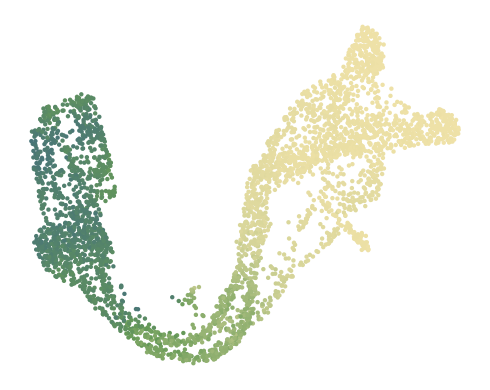

Saved: ./velovae_std/17_embedding.png


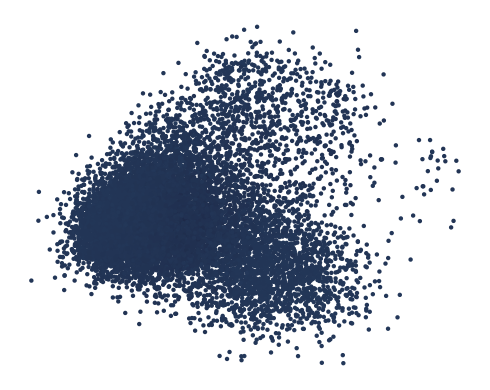

Saved: ./velovae_std/18_embedding.png


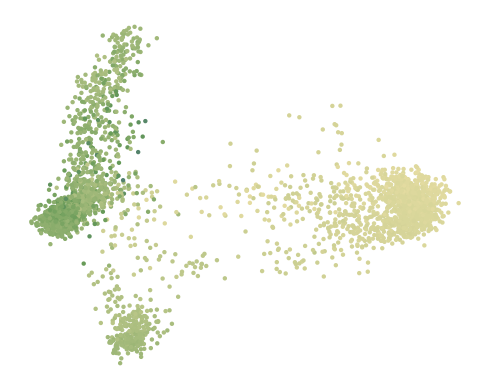

Saved: ./velovae_std/19_embedding.png


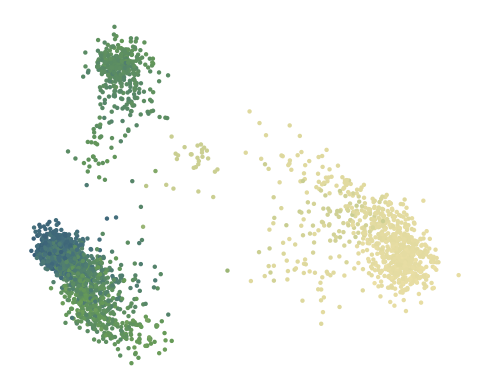

Saved: ./velovae_std/20_embedding.png


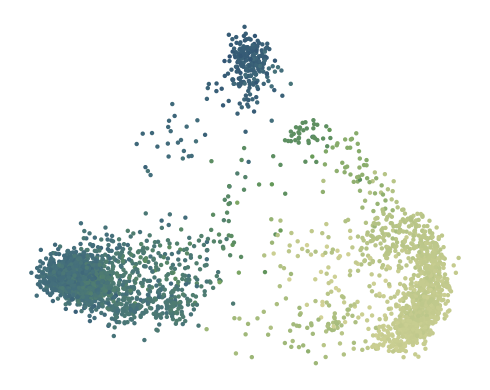

Saved: ./velovae_std/21_embedding.png


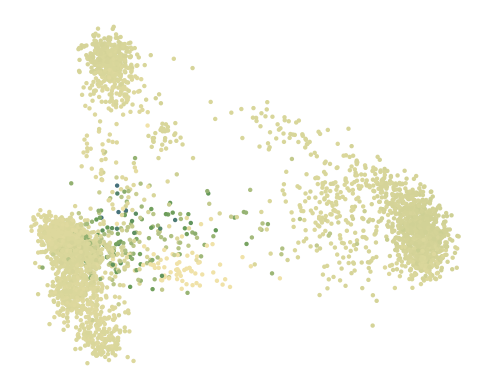

In [5]:
for key, data in datasets.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    
    x = data['embedding'][:, 0]
    y = data['embedding'][:, 1]
    color_val = data['scaled_uncertainty']
    
    sc = ax.scatter(
        x, y, 
        c=color_val,
        cmap=cmap_custom,
        norm=norm,
        s=10,
        linewidths=0,
    )

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()

    save_path = f"./{method}/{key}_embedding.png"
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)

In [6]:
method = "cell2fate"
DATA_DIR = Path(f"{method}")

In [7]:
data_configs = {
    "04": ("data04", "uncertainty_data04.npy",   "emb_coords_data04.npy"),
    "17": ("data17", "uncertainty_data17.npy", "emb_coords_data17.npy"),
    "18": ("data18", "uncertainty_data18.npy", "emb_coords_data18.npy"),
    "19": ("data19", "uncertainty_data19.npy", "emb_coords_data19.npy"),
    "20": ("data20", "uncertainty_data20.npy", "emb_coords_data20.npy"),
    "21": ("data21", "uncertainty_data21.npy", "emb_coords_data21.npy"),
}

datasets = {}
for key, (subdir, u_name, emb_name) in data_configs.items():
    datasets[key] = {
        "uncertainty": np.load(DATA_DIR / subdir / u_name),
        "embedding":   np.load(DATA_DIR / subdir / emb_name)
    }

all_uncertainties = [d["uncertainty"] for d in datasets.values()]
global_min = min(arr.min() for arr in all_uncertainties)
global_max = max(arr.max() for arr in all_uncertainties)
global_range = global_max - global_min

for key in datasets:
    raw_score = datasets[key]["uncertainty"]
    datasets[key]["scaled_uncertainty"] = (raw_score - global_min) / global_range

In [8]:
morandi_viridis_list = [
    "#F0E2A8",
    "#669A57",
    "#45707C",
    "#2B4C71",
    "#1E2A49"
]
cmap_custom = LinearSegmentedColormap.from_list("uncertainty_cmap", morandi_viridis_list, N=256)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

Saved: ./cell2fate/04_embedding.png


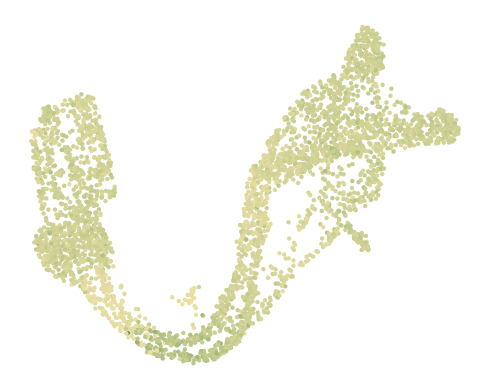

Saved: ./cell2fate/17_embedding.png


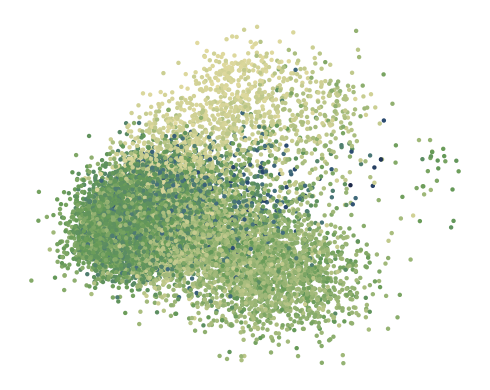

Saved: ./cell2fate/18_embedding.png


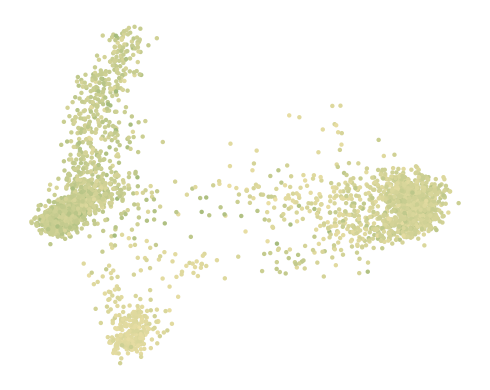

Saved: ./cell2fate/19_embedding.png


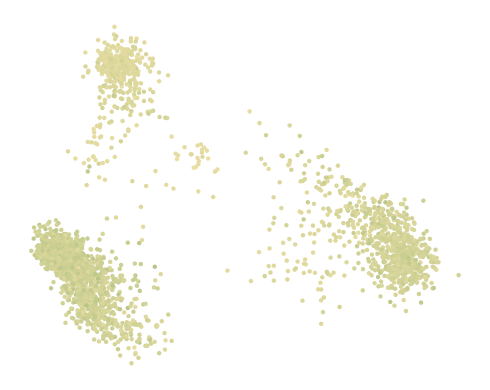

Saved: ./cell2fate/20_embedding.png


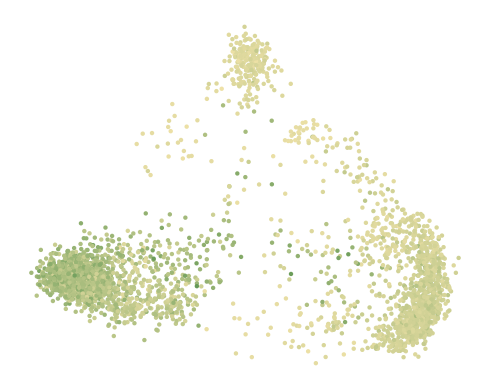

Saved: ./cell2fate/21_embedding.png


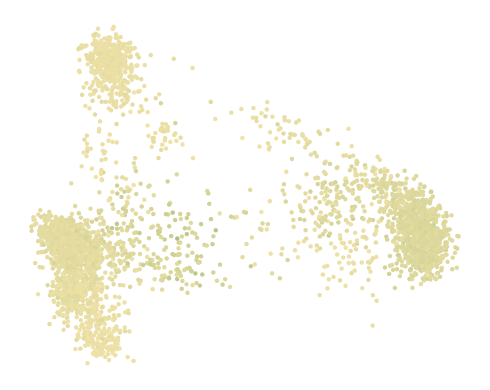

In [9]:
for key, data in datasets.items():
    fig, ax = plt.subplots(figsize=(5, 4))
    
    x = data['embedding'][:, 0]
    y = data['embedding'][:, 1]
    color_val = data['scaled_uncertainty']
    
    sc = ax.scatter(
        x, y, 
        c=color_val,
        cmap=cmap_custom,
        norm=norm,
        s=10,
        linewidths=0,
    )

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()

    save_path = f"./{method}/{key}_embedding.png"
    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)